# Évolution des prénoms en France (1900–2025)

Exploration du fichier open data de l'INSEE sur les prénoms donnés en France depuis 1900.

Source : [Fichier des prénoms — INSEE](https://www.insee.fr/fr/statistiques/8595130) (édition 2025, fichier national).

In [1]:
%matplotlib inline
import sys
sys.path.append("../src")

import matplotlib.pyplot as plt

from prenoms.data import load_nat_file
from prenoms.analysis import annee_pic, comparer_prenoms, evolution_prenom, palmares

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

df = load_nat_file("../data/raw/prenoms-2025-nat.csv")
df.head()

,prenom,sexe,annee,naissances,rang
0,A'LIA,F,2014,5,7235
1,AABAN,M,2018,5,6020
2,AADAM,M,2009,5,4123
3,AADAM,M,2014,5,5848
4,AADAM,M,2015,5,5517


## Aperçu général

In [2]:
print(f"{len(df):,} lignes")
print(f"{df['prenom'].nunique():,} prénoms distincts")
print(f"Période couverte : {df['annee'].min()} - {df['annee'].max()}")
print(f"Total des naissances enregistrées : {df['naissances'].sum():,}")

724,644 lignes
49,162 prénoms distincts
Période couverte : 1900 - 2025
Total des naissances enregistrées : 87,644,315


## Évolution d'un prénom : Gabriel

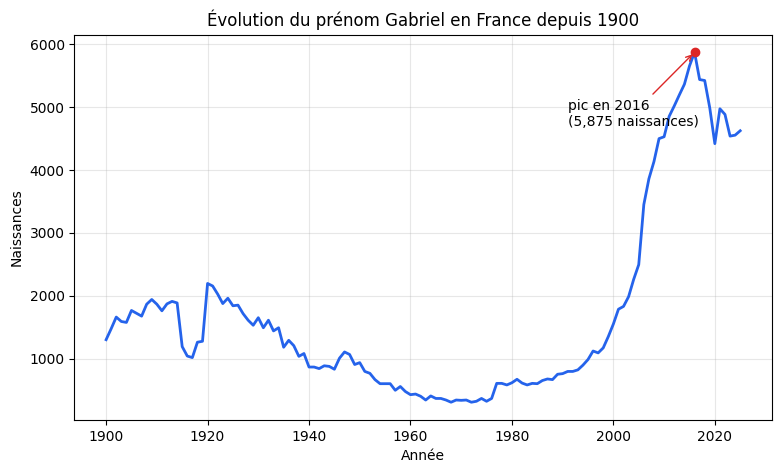

In [3]:
evo_gabriel = evolution_prenom(df, "Gabriel", sexe="M")
annee_du_pic, valeur_du_pic = annee_pic(df, "Gabriel", sexe="M")

fig, ax = plt.subplots()
ax.plot(evo_gabriel["annee"], evo_gabriel["naissances"], color="#2563eb", linewidth=2)
ax.scatter([annee_du_pic], [valeur_du_pic], color="#dc2626", zorder=5)
ax.annotate(
    f"pic en {annee_du_pic}\n({valeur_du_pic:,} naissances)",
    xy=(annee_du_pic, valeur_du_pic),
    xytext=(annee_du_pic - 25, valeur_du_pic * 0.8),
    arrowprops=dict(arrowstyle="->", color="#dc2626"),
)
ax.set_title("Évolution du prénom Gabriel en France depuis 1900")
ax.set_xlabel("Année")
ax.set_ylabel("Naissances")
plt.show()

## Comparer plusieurs prénoms : le podium 2025

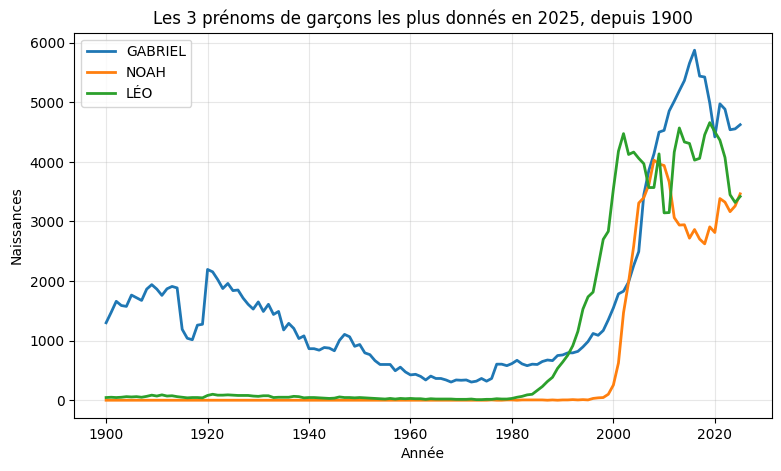

In [4]:
top3_garcons_2025 = palmares(df, 2025, "M", top=3)["prenom"].tolist()
comparaison = comparer_prenoms(df, top3_garcons_2025, sexe="M")

fig, ax = plt.subplots()
for prenom in top3_garcons_2025:
    ax.plot(comparaison["annee"], comparaison[prenom], label=prenom, linewidth=2)
ax.set_title("Les 3 prénoms de garçons les plus donnés en 2025, depuis 1900")
ax.set_xlabel("Année")
ax.set_ylabel("Naissances")
ax.legend()
plt.show()

## Palmarès 2025

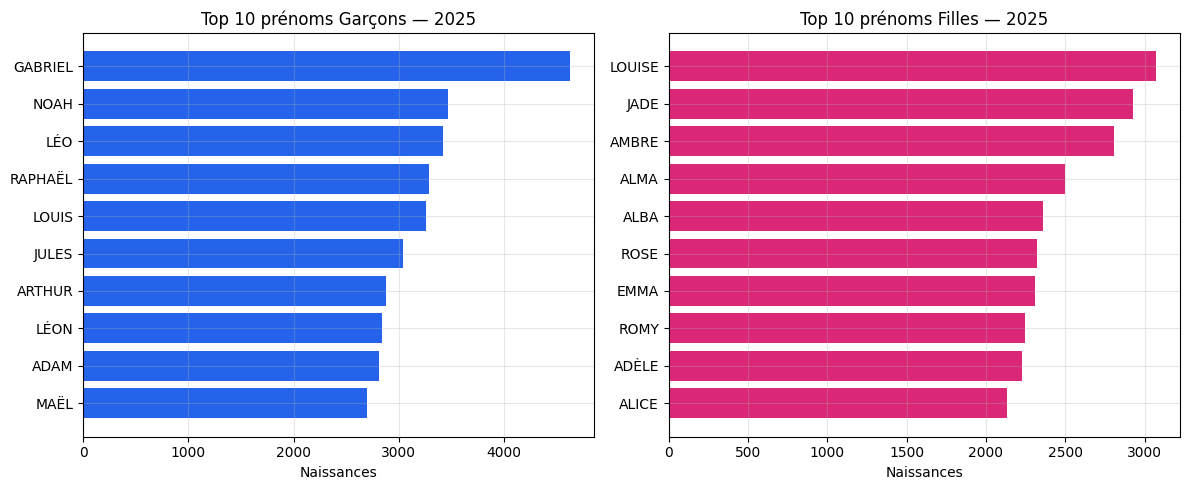

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, sexe, couleur, titre in [
    (axes[0], "M", "#2563eb", "Garçons"),
    (axes[1], "F", "#db2777", "Filles"),
]:
    top10 = palmares(df, 2025, sexe, top=10).sort_values("rang", ascending=False)
    ax.barh(top10["prenom"], top10["naissances"], color=couleur)
    ax.set_title(f"Top 10 prénoms {titre} — 2025")
    ax.set_xlabel("Naissances")

plt.tight_layout()
plt.show()

## Et ensuite ?

Cette exploration valide le module `prenoms` (chargement + analyse). La suite du projet transforme ces mêmes fonctions en application interactive Streamlit, pour rechercher n'importe quel prénom sans relancer de notebook.